# Phase 3 — Spatial analytics

Mérida Urban Intelligence · Geospatial Data Warehouse

Every table and map in this notebook is computed from the warehouse views (`dw.vw_kpi_ageb`,
`dw.vw_kpi_ageb_geo`) through `src/analysis/dw_io.py`; no raw file or intermediate DataFrame is
read. Run `python -m src.run_pipeline` first.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src import config
from src.analysis import correlations, kpi_maps, spatial_autocorrelation
from src.analysis.dw_io import crime_loaded, read_from_dw

pd.set_option("display.float_format", lambda v: f"{v:,.4g}")
kpi = read_from_dw("vw_kpi_ageb")
print("AGEBs:", len(kpi), "| crime source loaded:", crime_loaded())

AGEBs: 526 | crime source loaded: False


## 1. Analytical dataset

One row per urban AGEB. Per-capita indicators of AGEBs with fewer than 100 residents are
arithmetically valid but extreme (commercial and institutional land), so they are flagged by the
warehouse (`low_population`) and left out of every per-capita statistic.

In [2]:
cols = ["pop_density_km2", "pea_rate_pct", "share_65_plus_pct", "business_density_km2",
        "retail_density_km2", "service_density_km2", "businesses_per_1000",
        "crimes_total", "crime_rate_per_1000", "crimes_per_100_businesses"]
summary = kpi[cols].describe(percentiles=[0.25, 0.5, 0.75]).T[["count", "min", "25%", "50%", "75%", "max"]]
print("AGEBs flagged low_population:", int(kpi["low_population"].sum()))
summary

AGEBs flagged low_population: 32


,count,min,25%,50%,75%,max
pop_density_km2,526,0,"2,138","4,513","6,607",1.806e+04
pea_rate_pct,516,40.91,59.56,62.89,67.02,95.92
share_65_plus_pct,506,0,4.413,7.52,13.77,34.29
business_density_km2,526,0,97.65,224.8,345.4,"5,246"
retail_density_km2,526,0,28.55,69.5,112.6,"3,397"
service_density_km2,526,0,43.1,114.6,185.2,"1,633"
businesses_per_1000,520,0,28.38,46.59,71.81,2.667e+04


## 2. Geographic distribution

Quantile choropleths: each colour holds one fifth of the AGEBs, so the maps compare relative
position across the city, not absolute differences.

maps written to outputs\maps: 8


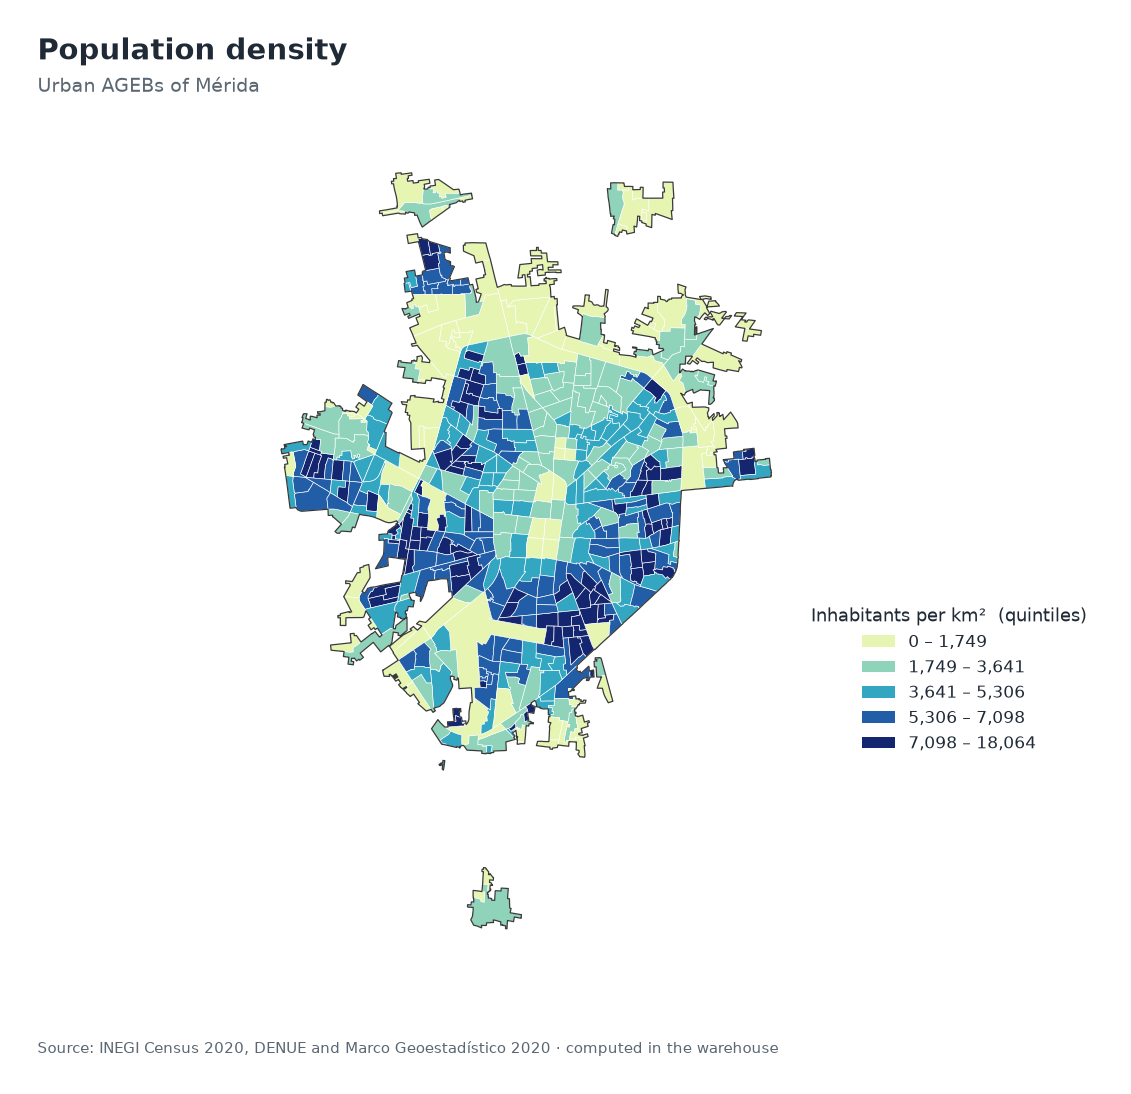

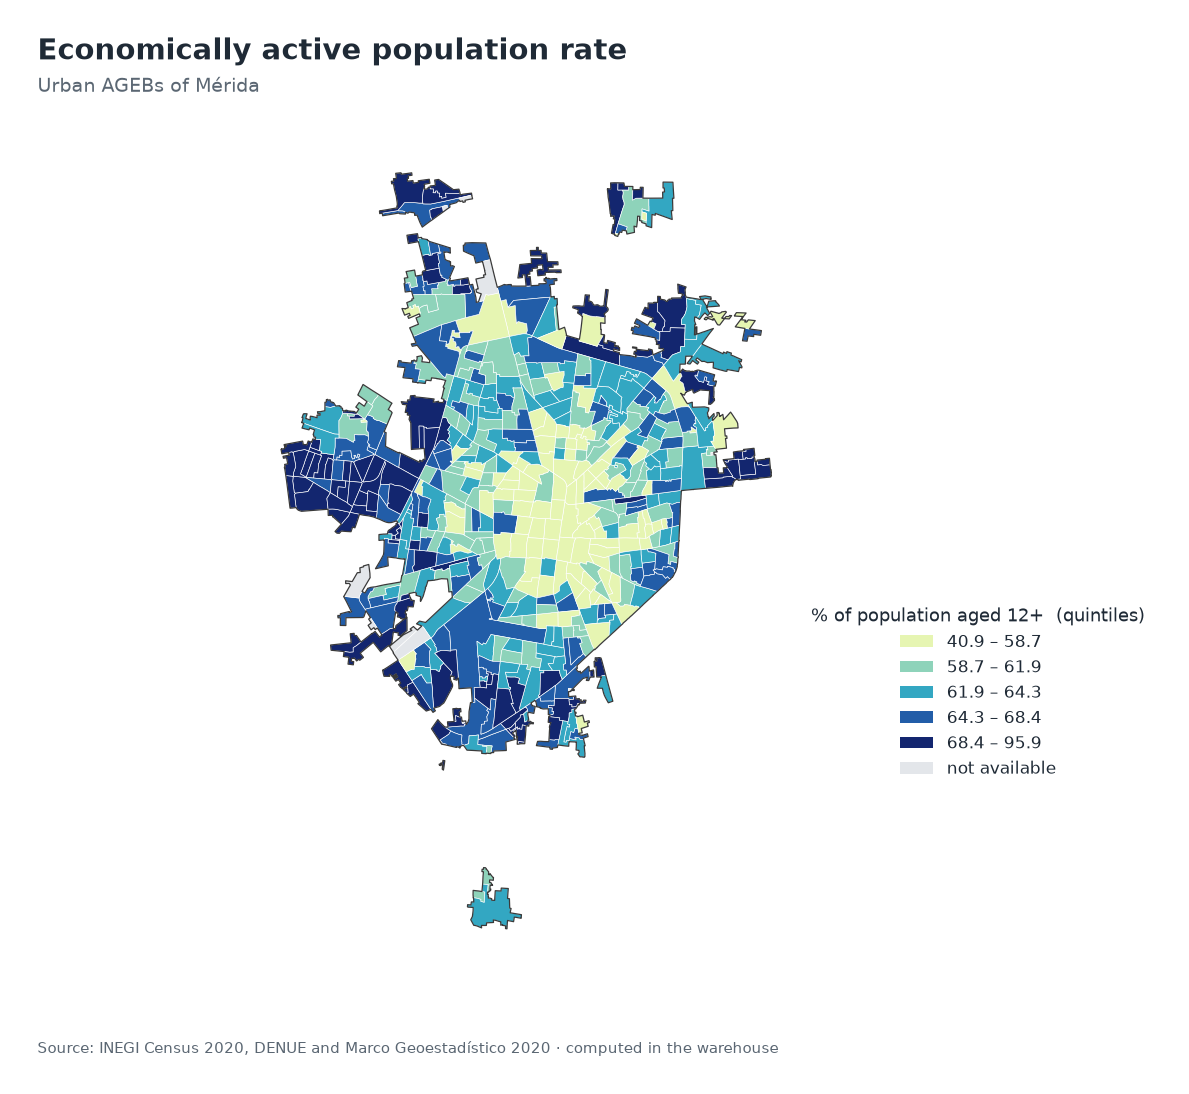

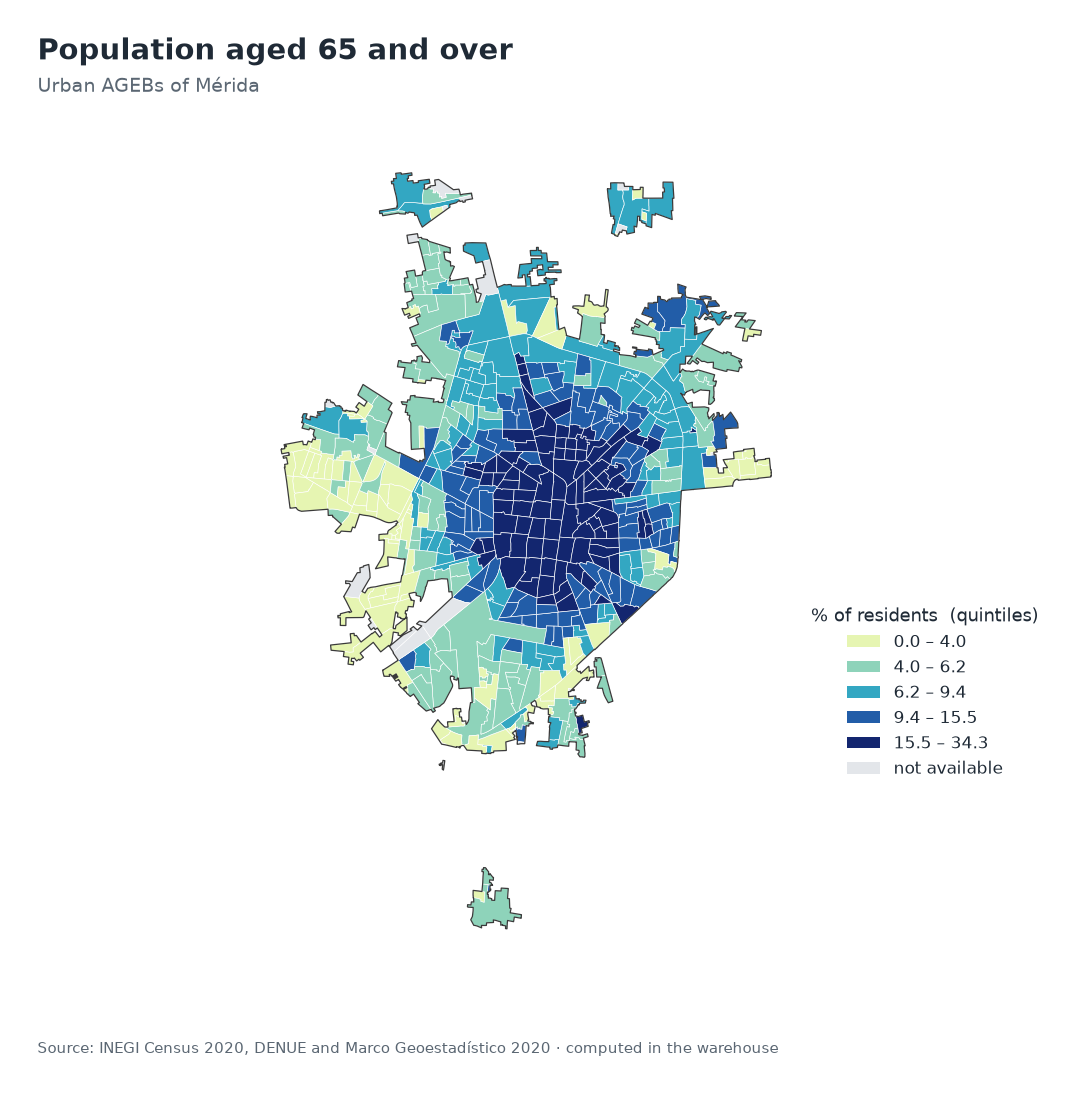

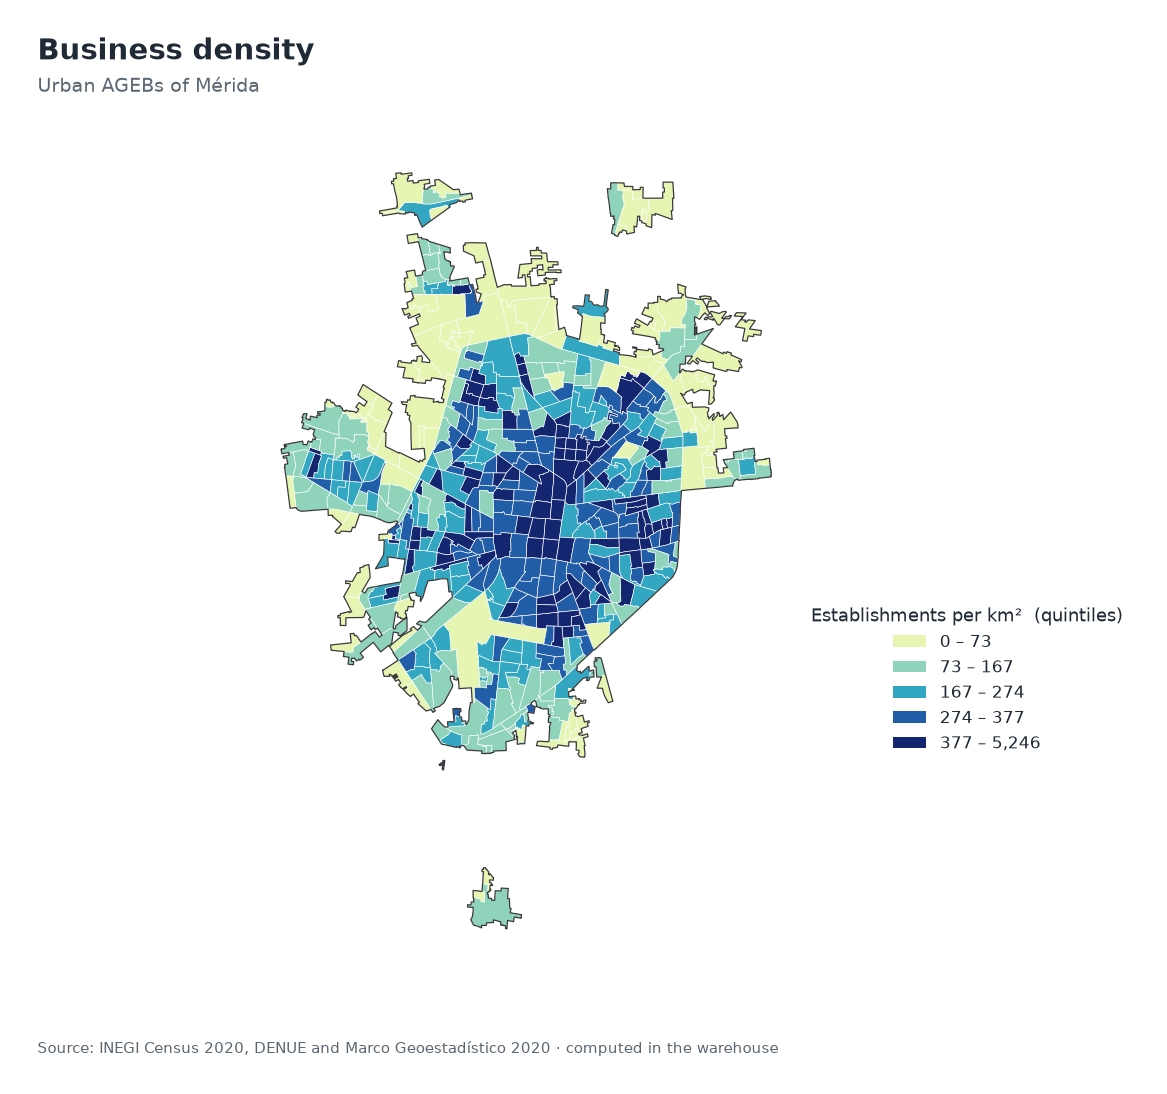

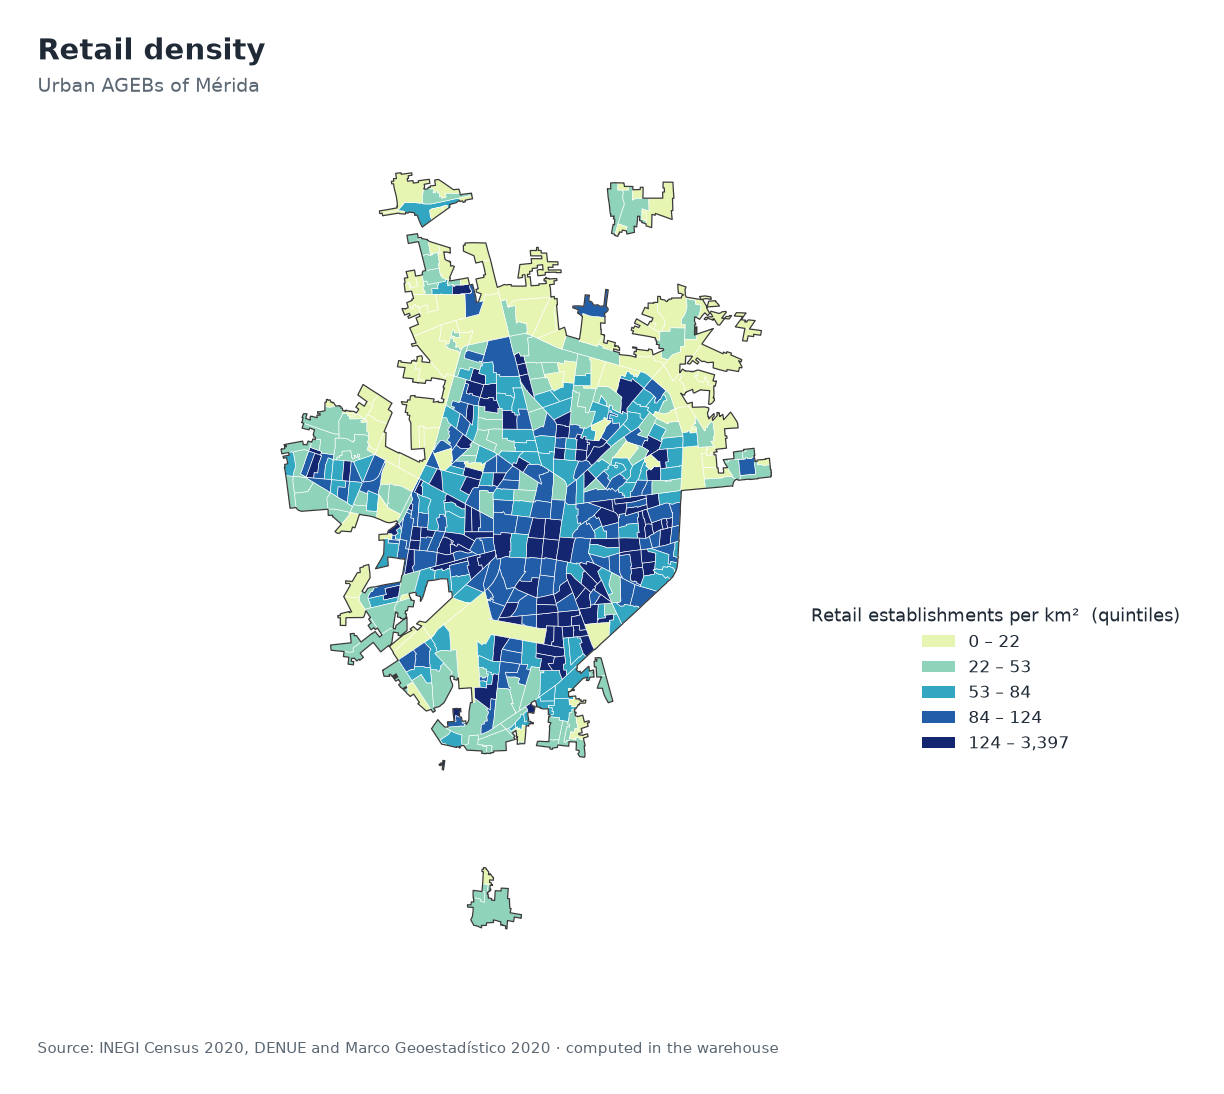

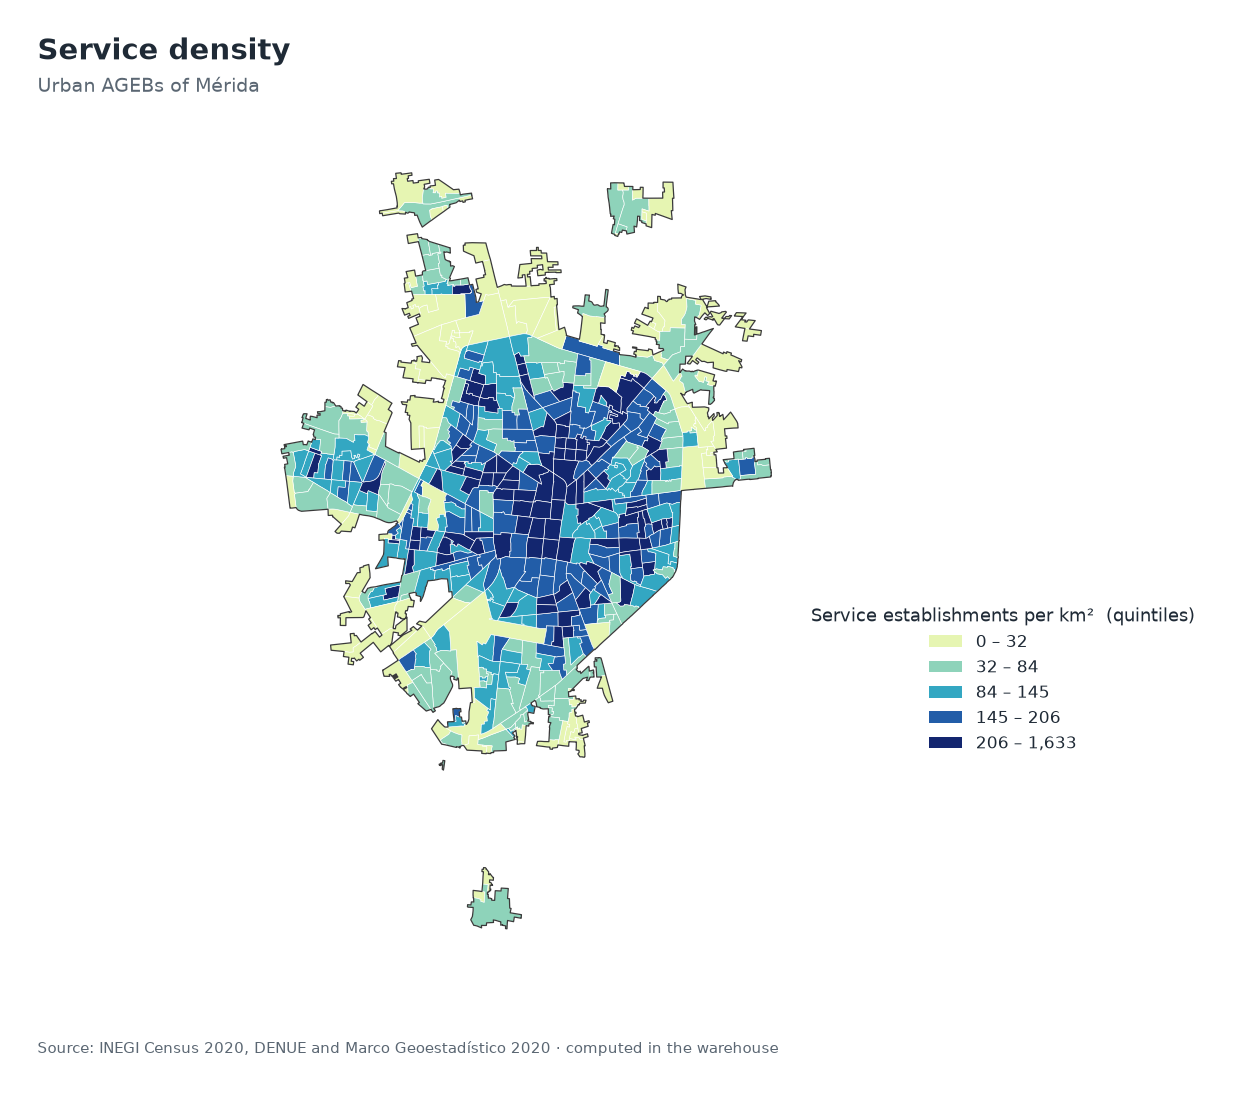

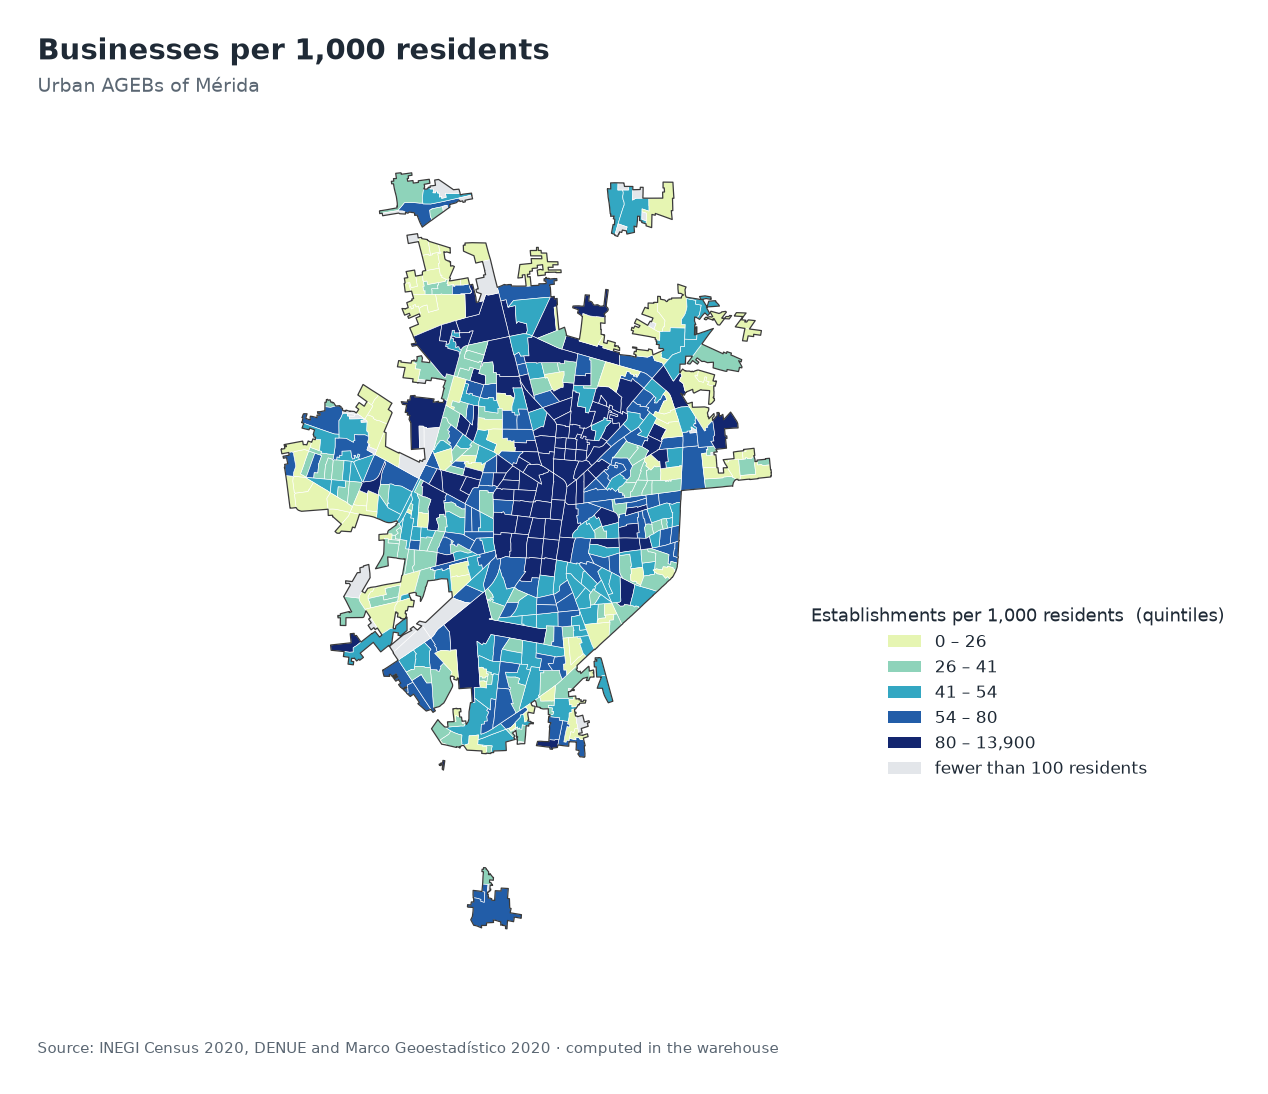

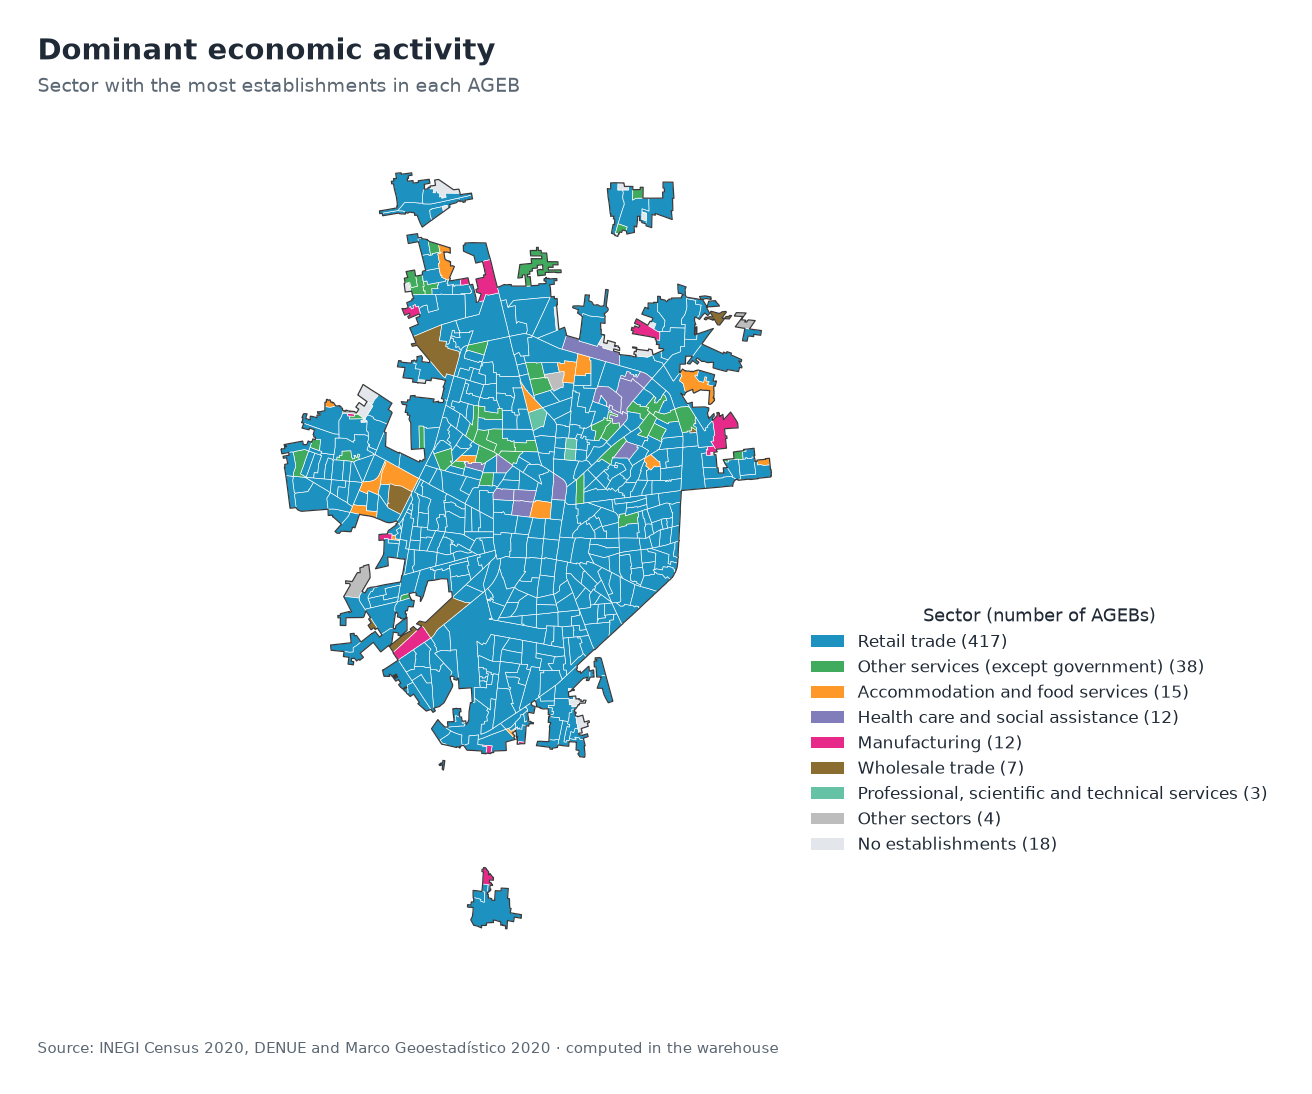

In [3]:
kpi_maps.main()
for name in sorted(config.MAPS.glob("0*.png")):
    display(Image(filename=str(name), width=520))

**Reading.** Residents and businesses do not concentrate in the same places. Population density
is highest in a ring of residential AGEBs around the centre, especially to the south and west,
while the historic centre has few residents. Business, retail and service density peak in the
centre and along the main corridors. Retail trade is the dominant activity in most AGEBs; services
dominate in a group of central and northern AGEBs.

## 3. Correlation

Spearman's ρ is the primary measure because the indicators are right-skewed and contain extreme
AGEBs; Pearson's r on log(1 + x) is reported as a check on the transformed scale.

In [4]:
correlations.main()
corr = pd.read_csv(config.OUTPUTS / "correlations.csv")
corr

                x                    y   n  spearman_rho  spearman_p  pearson_r_log  pearson_p_log  excluded_low_population
  pop_density_km2 business_density_km2 526        0.5536   1.445e-43         0.5811      8.057e-49                    False
  pop_density_km2  businesses_per_1000 494       -0.3101   1.799e-12        -0.1855      3.342e-05                     True
     pea_rate_pct  businesses_per_1000 494       -0.3531   5.919e-16        -0.3099      1.858e-12                     True
share_65_plus_pct  service_density_km2 491         0.568   2.731e-43         0.4324      8.743e-24                     True


,x,y,n,spearman_rho,spearman_p,pearson_r_log,pearson_p_log,excluded_low_population
0,pop_density_km2,business_density_km2,526,0.5536,1.445e-43,0.5811,8.057e-49,False
1,pop_density_km2,businesses_per_1000,494,-0.3101,1.799e-12,-0.1855,3.342e-05,True
2,pea_rate_pct,businesses_per_1000,494,-0.3531,5.919e-16,-0.3099,1.858e-12,True
3,share_65_plus_pct,service_density_km2,491,0.568,2.731e-43,0.4324,8.743e-24,True


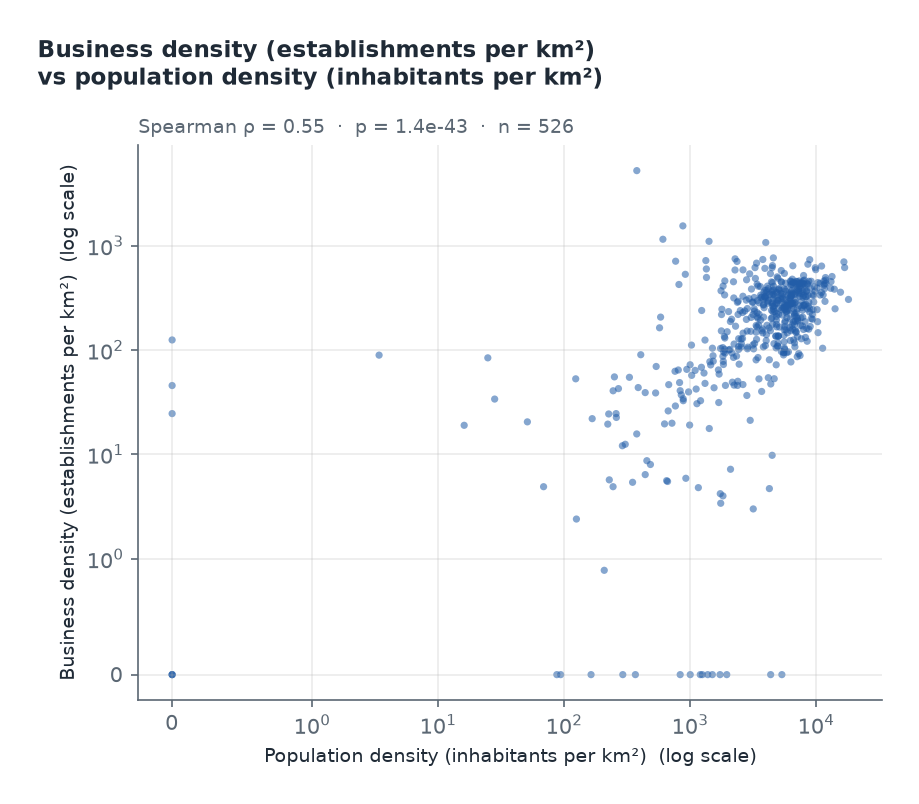

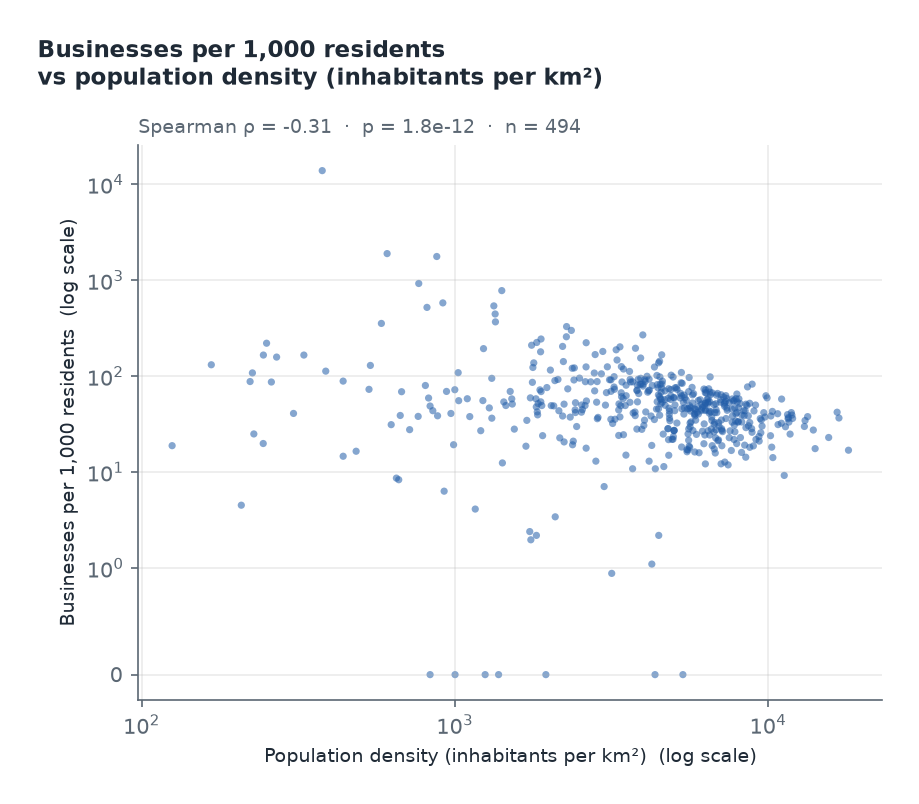

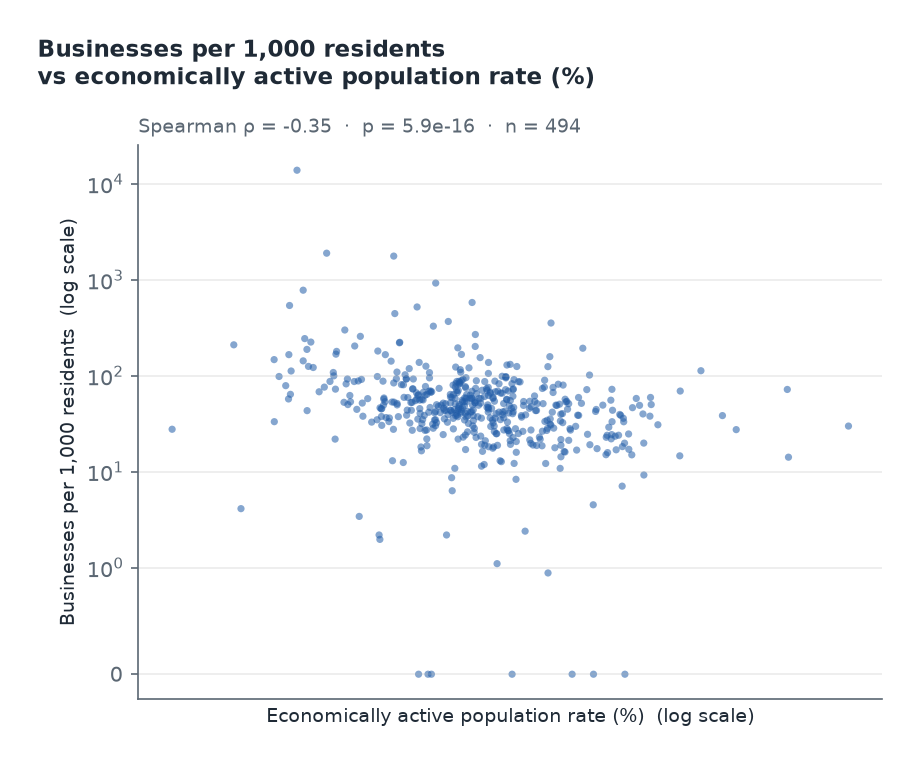

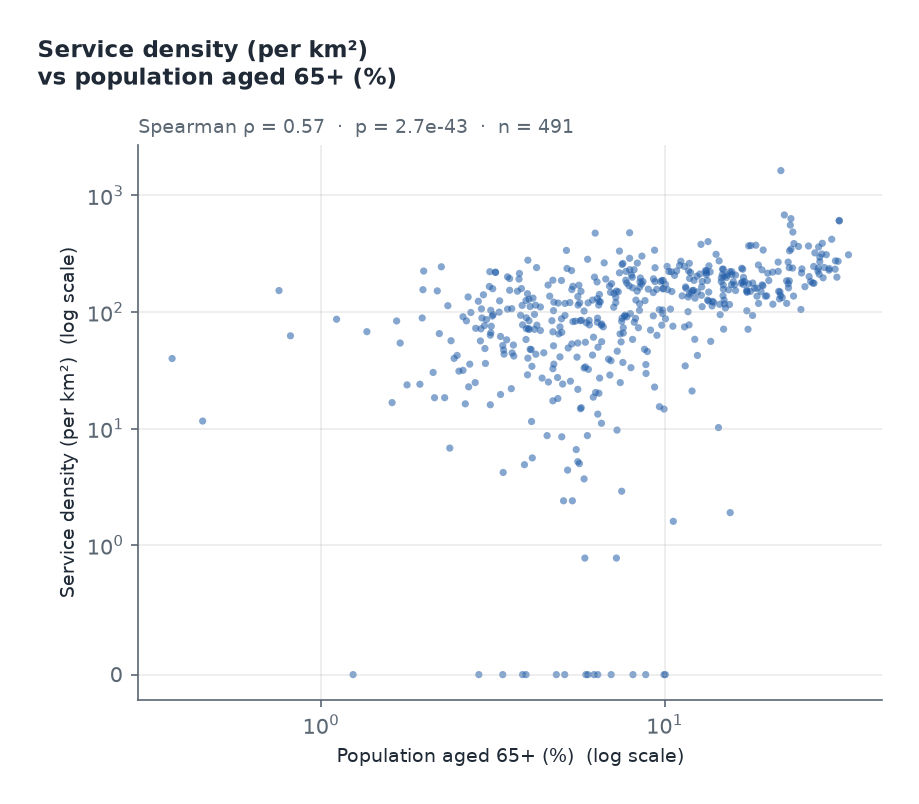

In [5]:
for name in sorted(config.FIGURES.glob("corr_*.png")):
    display(Image(filename=str(name), width=460))

**Reading.** Denser residential AGEBs also have more establishments per km², a moderate positive
association. Per resident the sign reverses: the most populated AGEBs have fewer businesses per
1,000 inhabitants, and AGEBs with a higher economically active population rate also have fewer
businesses per resident — typical of newer residential neighbourhoods where people live but do
not work. AGEBs with an older population have a higher service density, which matches the older,
central and service-rich areas of the city. These are associations between areas, not between
individuals, and they do not establish cause.

## 4. Spatial-neighbourhood rule

- **Rule:** Queen contiguity. Two AGEBs are neighbours when they share an edge or a vertex.
- **Weights:** row-standardised, so the spatial lag of an AGEB is the mean of its neighbours.
- **Values:** log(1 + x), because densities are strongly skewed and a few AGEBs would otherwise
  dominate the statistics.
- **Inference:** 999 random permutations with a fixed seed; pseudo p-values; α = 0.05.
- **Islands:** AGEBs with no contiguous neighbour (detached localities) are excluded and counted.

**Implications.** Influence is assumed only between touching AGEBs: two AGEBs separated by a road
reserve or an undeveloped strip are not neighbours even if they are close. Peripheral AGEBs are
larger and have fewer neighbours, so their local statistics rest on fewer values and are less
stable than those of the small central AGEBs. A different rule (k nearest neighbours, distance
bands) could change which AGEBs are flagged, although the global pattern is expected to hold.

In [6]:
spatial_autocorrelation.main()
moran = pd.read_csv(config.OUTPUTS / "moran_results.csv")
moran.dropna(axis=1, how="all")

           analysis                    x               y   n  islands_excluded  statistic  expected  z_sim  p_sim  n_not_significant  n_high_high  n_low_low  n_low_high  n_high_low
   global Moran's I      pop_density_km2                 524                 2     0.3678   -0.0019  12.58  0.001                NaN          NaN        NaN         NaN         NaN
   global Moran's I business_density_km2                 524                 2      0.505   -0.0019  17.07  0.001                NaN          NaN        NaN         NaN         NaN
   global Moran's I         pea_rate_pct                 491                 3     0.5468    -0.002  18.07  0.001                NaN          NaN        NaN         NaN         NaN
   global Moran's I  businesses_per_1000                 491                 3     0.4553    -0.002  15.82  0.001                NaN          NaN        NaN         NaN         NaN
               LISA      pop_density_km2                 524                 2        NaN      

,analysis,x,y,n,islands_excluded,statistic,expected,z_sim,p_sim,n_not_significant,n_high_high,n_low_low,n_low_high,n_high_low
0,global Moran's I,pop_density_km2,NaN,524,2,0.3678,-0.0019,12.58,0.001,NaN,NaN,NaN,NaN,NaN
1,global Moran's I,business_density_km2,NaN,524,2,0.505,-0.0019,17.07,0.001,NaN,NaN,NaN,NaN,NaN
2,global Moran's I,pea_rate_pct,NaN,491,3,0.5468,-0.002,18.07,0.001,NaN,NaN,NaN,NaN,NaN
3,global Moran's I,businesses_per_1000,NaN,491,3,0.4553,-0.002,15.82,0.001,NaN,NaN,NaN,NaN,NaN
4,LISA,pop_density_km2,NaN,524,2,NaN,NaN,NaN,NaN,398,93,23,5,5
5,LISA,business_density_km2,NaN,524,2,NaN,NaN,NaN,NaN,355,120,41,4,4
6,bivariate Moran's I,business_density_km2,pop_density_km2,524,2,0.3154,NaN,7.753,0.001,NaN,NaN,NaN,NaN,NaN


## 5. Global spatial autocorrelation

Every indicator tested shows positive and significant global Moran's I (pseudo p = 0.001, the
minimum attainable with 999 permutations): AGEBs resemble their neighbours far more than a random
arrangement would produce. Similar values cluster in space, which also means that ordinary
statistical tests that assume independent observations overstate the evidence in section 3.

## 6. Local spatial patterns (LISA)

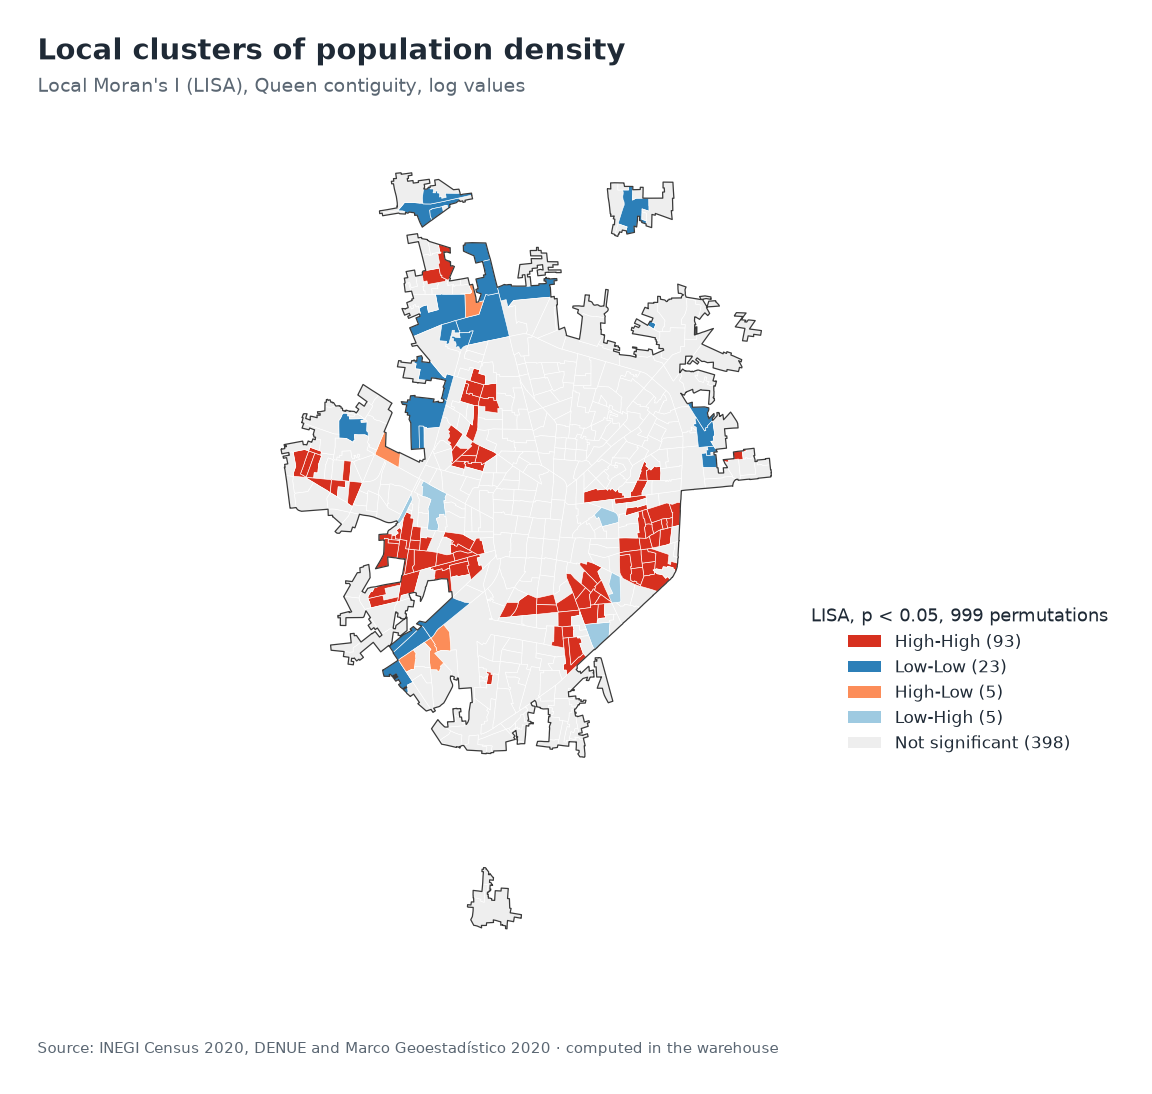

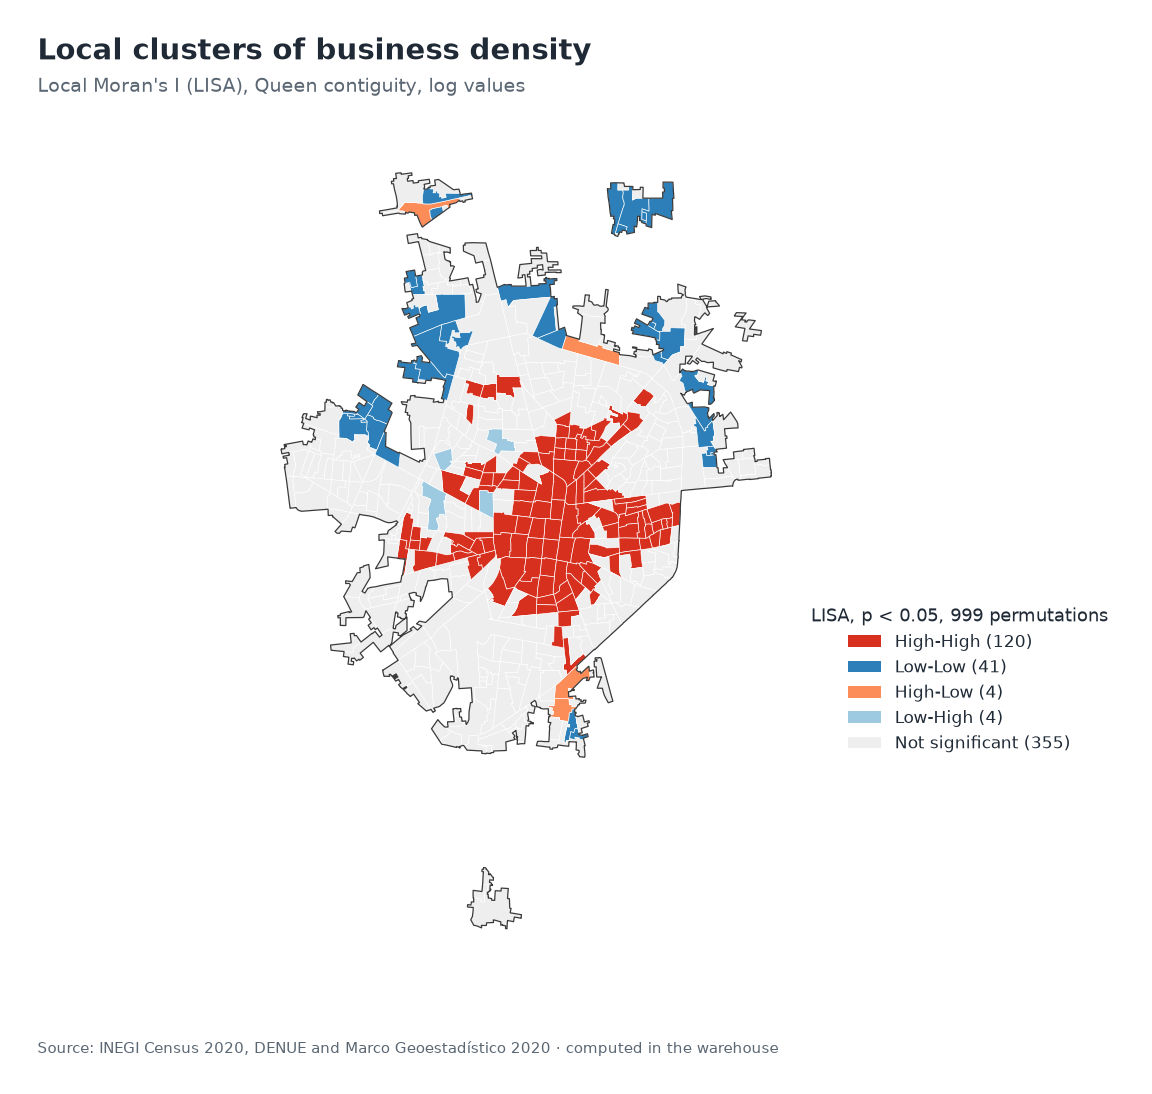

In [7]:
for name in sorted(config.MAPS.glob("lisa_*.png")):
    display(Image(filename=str(name), width=520))

**Reading.** Business density forms one large High-High cluster over the historic centre and its
extensions, and Low-Low clusters on the northern periphery, from the north-west to the north-east. Population density has
High-High clusters in residential belts away from the centre. The few High-Low and Low-High AGEBs
are spatial outliers: an AGEB that differs sharply from its surroundings, such as a commercial
strip inside a residential area.

## 7. Bivariate spatial relationship

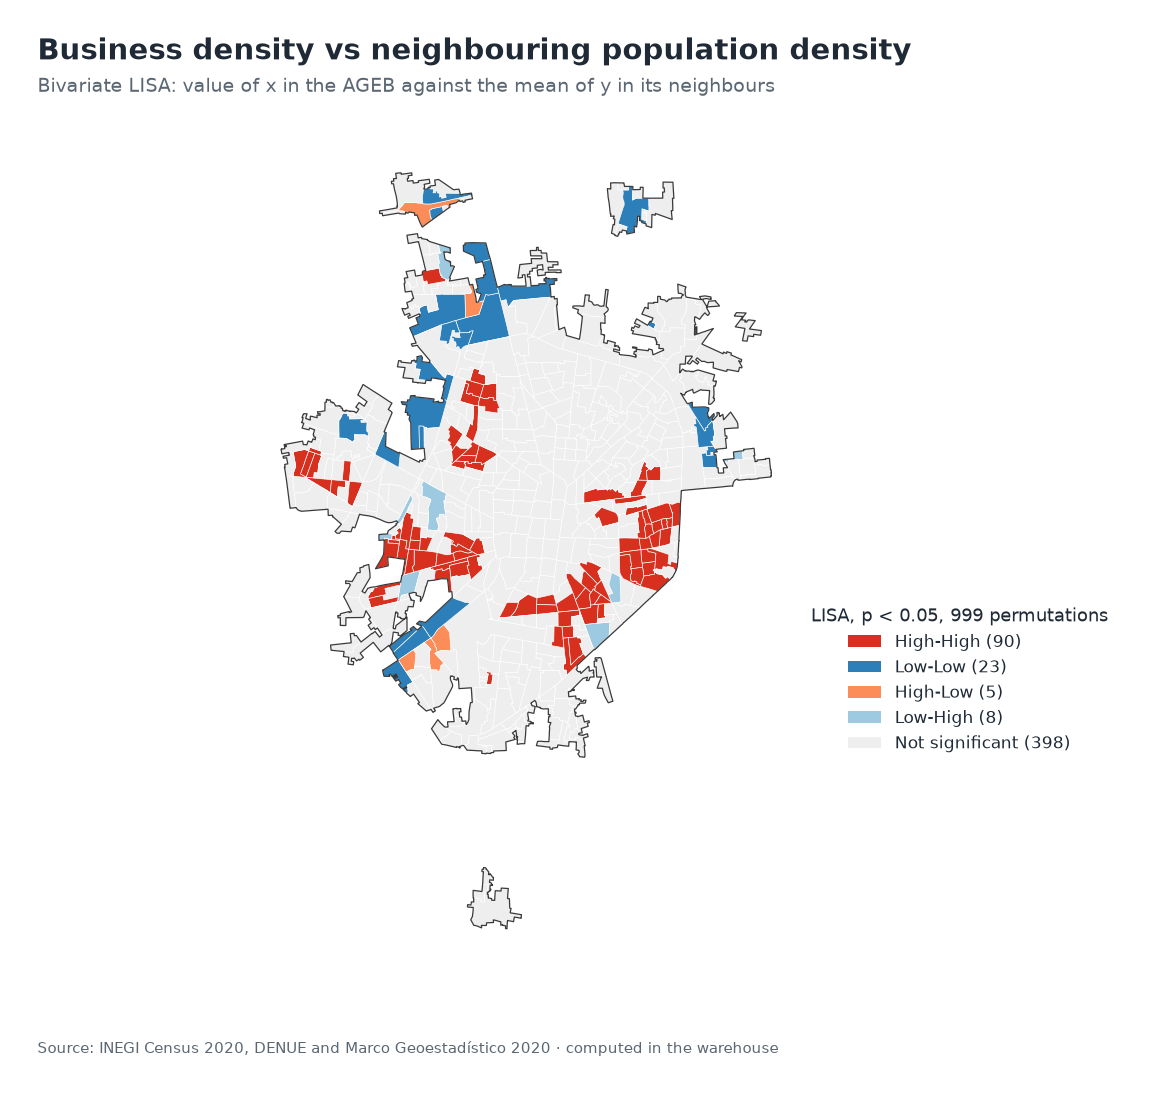

,analysis,x,y,n,islands_excluded,statistic,z_sim,p_sim
6,bivariate Moran's I,business_density_km2,pop_density_km2,524,2,0.3154,7.753,0.001


In [8]:
for name in sorted(config.MAPS.glob("bilisa_*.png")):
    display(Image(filename=str(name), width=520))
moran[moran["analysis"] == "bivariate Moran's I"].dropna(axis=1, how="all")

**Reading.** Bivariate Moran's I compares business density in each AGEB with the average
population density of its neighbours. The positive and significant value indicates that business
activity tends to sit next to populated areas. When the crime source is loaded, the same analysis
runs for business density against crime rate.

## 8. Public safety

The georeferenced incident source is pending confirmation. The warehouse, the KPI views and every
analysis above already include the crime indicators: when an incident file is loaded, the
pipeline adds the crime maps, the crime correlations, the global and local Moran's I of the crime
rate and the bivariate relationship between business density and crime. Until then, the crime
KPIs are deliberately NULL, never zero, so that "no data" is not mistaken for "no incidents".

## 9. Cautions

- **Association is not causation.** Every result describes how areas co-vary in space.
- **Ecological fallacy.** Patterns between AGEBs say nothing about individual people or firms.
- **Modifiable areal unit problem.** Other boundaries or another unit could change coefficients.
- **Reference dates.** Population is from 2020; establishments are from the latest DENUE edition.
- **Spatial dependence.** Clustering reduces the effective sample size of ordinary tests.